# Week 1 — Data Loading & EDA
**Date:** March 2026  
**Status:** Complete  
**Key findings:** Scores up post-2020, sixes increasing, Kohli all-time top scorer (8671 runs)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

#Display
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)
plt.style.use("dark_background")

print("Libraries imported :)")

Libraries imported :)


In [3]:
# Load the two main files
matches = pd.read_csv('../data/matches_updated_ipl_upto_2025.csv')
deliveries = pd.read_csv('../data/deliveries_updated_ipl_upto_2025.csv')

print("Datasets loaded :)")
print(f"\nMatches shape: {matches.shape}")
print(f"Deliveries shape: {deliveries.shape}")

Datasets loaded :)

Matches shape: (1169, 28)
Deliveries shape: (278205, 20)


In [4]:
# Look at the first few rows
print("=== MATCHES DATAFRAME ===")
print(f"Seasons covered: {sorted(matches['season'].unique())}")
print(f"\nColumns:\n{list(matches.columns)}")
matches.head(3)

=== MATCHES DATAFRAME ===
Seasons covered: ['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022', '2023', '2024', '2025']

Columns:
['season', 'venue', 'event', 'winner_runs', 'umpire2', 'toss_winner', 'date', 'neutralvenue', 'umpire1', 'city', 'reserve_umpire', 'winner', 'eliminator', 'date1', 'method', 'team1', 'toss_decision', 'gender', 'team2', 'balls_per_over', 'winner_wickets', 'tv_umpire', 'player_of_match', 'match_referee', 'outcome', 'date2', 'match_number', 'matchId']


,season,venue,event,winner_runs,umpire2,toss_winner,date,neutralvenue,umpire1,city,reserve_umpire,winner,eliminator,date1,method,team1,toss_decision,gender,team2,balls_per_over,winner_wickets,tv_umpire,player_of_match,match_referee,outcome,date2,match_number,matchId
0,2007/08,M Chinnaswamy Stadium,Indian Premier League,140.00,RE Koertzen,Royal Challengers Bangalore,2008-04-18,NaN,Asad Rauf,Bangalore,VN Kulkarni,Kolkata Knight Riders,NaN,NaN,NaN,Royal Challengers Bangalore,field,male,Kolkata Knight Riders,6,NaN,AM Saheba,BB McCullum,J Srinath,NaN,NaN,1.00,335982
1,2007/08,"Punjab Cricket Association Stadium, Mohali",Indian Premier League,33.00,SL Shastri,Chennai Super Kings,2008-04-19,NaN,MR Benson,Chandigarh,MSS Ranawat,Chennai Super Kings,NaN,NaN,NaN,Kings XI Punjab,bat,male,Chennai Super Kings,6,NaN,RB Tiffin,MEK Hussey,S Venkataraghavan,NaN,NaN,2.00,335983
2,2007/08,Feroz Shah Kotla,Indian Premier League,NaN,GA Pratapkumar,Rajasthan Royals,2008-04-19,NaN,Aleem Dar,Delhi,NaN,Delhi Daredevils,NaN,NaN,NaN,Delhi Daredevils,bat,male,Rajasthan Royals,6,9.00,IL Howell,MF Maharoof,GR Viswanath,NaN,NaN,3.00,335984


In [5]:
print("=== DELIVERIES DATAFRAME ===")
print(f"\nColumns:\n{list(deliveries.columns)}")
deliveries.head(3)

=== DELIVERIES DATAFRAME ===

Columns:
['matchId', 'inning', 'over_ball', 'over', 'ball', 'batting_team', 'bowling_team', 'batsman', 'non_striker', 'bowler', 'batsman_runs', 'extras', 'isWide', 'isNoBall', 'Byes', 'LegByes', 'Penalty', 'dismissal_kind', 'player_dismissed', 'date']


,matchId,inning,over_ball,over,ball,batting_team,bowling_team,batsman,non_striker,bowler,batsman_runs,extras,isWide,isNoBall,Byes,LegByes,Penalty,dismissal_kind,player_dismissed,date
0,335982,1,0.10,0,1,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,BB McCullum,P Kumar,0,1,NaN,NaN,NaN,1.00,NaN,NaN,NaN,2008-04-18
1,335982,1,0.20,0,2,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008-04-18
2,335982,1,0.30,0,3,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,1,1.00,NaN,NaN,NaN,NaN,NaN,NaN,2008-04-18


In [6]:
print("=== MISSING VALUES IN MATCHES ===")
missing_matches = matches.isnull().sum()
print(missing_matches[missing_matches > 0])

print("\n=== MISSING VALUES IN DELIVERIES ===")
missing_deliveries = deliveries.isnull().sum()
print(missing_deliveries[missing_deliveries > 0])

print("\n=== MATCHES BASIC STATS ===")
print(f"Total matches: {len(matches)}")
print(f"Total teams: {matches['team1'].nunique()}")
print(f"Total venues: {matches['venue'].nunique()}")
print(f"Total Player of Match awards: {matches['player_of_match'].nunique()} unique players")

print("\n=== DELIVERIES BASIC STATS ===")
print(f"Total deliveries: {len(deliveries)}")
print(f"Total batsmen: {deliveries['batsman'].nunique()}")
print(f"Total bowlers: {deliveries['bowler'].nunique()}")
print(f"Total runs scored: {deliveries['batsman_runs'].sum() + deliveries['extras'].sum()}")

=== MISSING VALUES IN MATCHES ===
winner_runs         638
neutralvenue       1092
city                 51
reserve_umpire       24
winner               23
eliminator         1154
date1              1167
method             1150
winner_wickets      554
tv_umpire             4
player_of_match       8
outcome            1146
date2              1167
match_number         70
dtype: int64

=== MISSING VALUES IN DELIVERIES ===
isWide              269125
isNoBall            277042
Byes                277504
LegByes             273990
Penalty             278203
dismissal_kind      264382
player_dismissed    264382
dtype: int64

=== MATCHES BASIC STATS ===
Total matches: 1169
Total teams: 19
Total venues: 59
Total Player of Match awards: 308 unique players

=== DELIVERIES BASIC STATS ===
Total deliveries: 278205
Total batsmen: 704
Total bowlers: 551
Total runs scored: 374283


In [7]:
# Drop columns we don't need
matches_clean = matches.drop(columns=[
    'date1', 'date2', 'eliminator', 'outcome', 
    'neutralvenue', 'match_referee', 'umpire1', 
    'umpire2', 'reserve_umpire', 'tv_umpire',
    'balls_per_over', 'gender', 'event'
])

# Fix date column
matches_clean['date'] = pd.to_datetime(matches_clean['date'])

# Standardize season column to just the year
matches_clean['season'] = matches_clean['season'].str[:4].astype(int)

# Fill missing city from venue
matches_clean['city'] = matches_clean['city'].fillna(
    matches_clean['venue'].str.split(',').str[0]
)

# For matches with no result (23 missing winners) - drop them
matches_clean = matches_clean.dropna(subset=['winner'])

# Reset index
matches_clean = matches_clean.reset_index(drop=True)

print(f"Matches cleaned!")
print(f"Shape after cleaning: {matches_clean.shape}")
print(f"Remaining columns: {list(matches_clean.columns)}")
print(f"\nSeasons: {sorted(matches_clean['season'].unique())}")
print(f"Missing values remaining:\n{matches_clean.isnull().sum()[matches_clean.isnull().sum() > 0]}")

Matches cleaned!
Shape after cleaning: (1146, 15)
Remaining columns: ['season', 'venue', 'winner_runs', 'toss_winner', 'date', 'city', 'winner', 'method', 'team1', 'toss_decision', 'team2', 'winner_wickets', 'player_of_match', 'match_number', 'matchId']

Seasons: [np.int64(2007), np.int64(2009), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Missing values remaining:
winner_runs        615
method            1127
winner_wickets     531
match_number        70
dtype: int64


In [8]:
# Fix the extras columns 
deliveries_clean = deliveries.copy()

for col in ['isWide', 'isNoBall', 'Byes', 'LegByes', 'Penalty']:
    deliveries_clean[col] = deliveries_clean[col].fillna(0)

# Create runs column (runs on that ball including extras)
deliveries_clean['total_runs'] = (
    deliveries_clean['batsman_runs'] + 
    deliveries_clean['extras']
)

# Create wicket column (1 if someone got out, 0 otherwise)
deliveries_clean['is_wicket'] = deliveries_clean['dismissal_kind'].notna().astype(int)

# Fix date column
deliveries_clean['date'] = pd.to_datetime(deliveries_clean['date'])

# Rename columns to be cleaner
deliveries_clean = deliveries_clean.rename(columns={
    'isWide': 'is_wide',
    'isNoBall': 'is_no_ball',
    'Byes': 'byes',
    'LegByes': 'leg_byes',
    'Penalty': 'penalty'
})

print("Deliveries cleaned!")
print(f"Shape: {deliveries_clean.shape}")
print(f"Columns: {list(deliveries_clean.columns)}")
print(f"\nTotal wickets in dataset: {deliveries_clean['is_wicket'].sum()}")
print(f"Total wides: {deliveries_clean['is_wide'].sum()}")
print(f"Total no balls: {(deliveries_clean['is_no_ball'] > 0).sum()}")

Deliveries cleaned!
Shape: (278205, 22)
Columns: ['matchId', 'inning', 'over_ball', 'over', 'ball', 'batting_team', 'bowling_team', 'batsman', 'non_striker', 'bowler', 'batsman_runs', 'extras', 'is_wide', 'is_no_ball', 'byes', 'leg_byes', 'penalty', 'dismissal_kind', 'player_dismissed', 'date', 'total_runs', 'is_wicket']

Total wickets in dataset: 13823
Total wides: 10884.0
Total no balls: 1163


In [10]:
# Merge deliveries with match info
master = deliveries_clean.merge(
    matches_clean[['matchId', 'season', 'venue', 'city', 'toss_winner', 
                   'toss_decision', 'winner', 'player_of_match', 'method']],
    on='matchId',
    how='left'
)

# Add match phase column (Powerplay / Middle / Death)
def get_phase(over):
    if over <= 6:
        return 'Powerplay'
    elif over <= 15:
        return 'Middle'
    else:
        return 'Death'

master['phase'] = master['over'].apply(get_phase)

# Add is_batting_team_winner column
master['batting_team_won'] = (master['batting_team'] == master['winner']).astype(int)

print("Master dataframe created!")
print(f"Shape: {master.shape}")
print(f"\nSample row:")
master.head(2)

Master dataframe created!
Shape: (278205, 32)

Sample row:


,matchId,inning,over_ball,over,ball,batting_team,bowling_team,batsman,non_striker,bowler,batsman_runs,extras,is_wide,is_no_ball,byes,leg_byes,penalty,dismissal_kind,player_dismissed,date,total_runs,is_wicket,season,venue,city,toss_winner,toss_decision,winner,player_of_match,method,phase,batting_team_won
0,335982,1,0.10,0,1,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,BB McCullum,P Kumar,0,1,0.00,0.00,0.00,1.00,0.00,NaN,NaN,2008-04-18,1,0,2007.00,M Chinnaswamy Stadium,Bangalore,Royal Challengers Bangalore,field,Kolkata Knight Riders,BB McCullum,NaN,Powerplay,1
1,335982,1,0.20,0,2,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,0,0.00,0.00,0.00,0.00,0.00,NaN,NaN,2008-04-18,0,0,2007.00,M Chinnaswamy Stadium,Bangalore,Royal Challengers Bangalore,field,Kolkata Knight Riders,BB McCullum,NaN,Powerplay,1


In [12]:
# Save to data folder
master.to_csv('../data/master_ipl.csv', index=False)
matches_clean.to_csv('../data/matches_clean.csv', index=False)
deliveries_clean.to_csv('../data/deliveries_clean.csv', index=False)

print("All clean files saved to data/ folder!")
print("\nFiles saved:")
print("  → master_ipl.csv        (main file you'll use for everything)")
print("  → matches_clean.csv     (match-level data)")
print("  → deliveries_clean.csv  (ball-by-ball data)")

All clean files saved to data/ folder!

Files saved:
  → master_ipl.csv        (main file you'll use for everything)
  → matches_clean.csv     (match-level data)
  → deliveries_clean.csv  (ball-by-ball data)


In [13]:
print("=== SANITY CHECKS ===\n")

# Check 1: Top run scorers all time
print("TOP 10 RUN SCORERS (ALL TIME):")
top_batsmen = (master[master['is_wide'] == 0]  # exclude wides from batsman stats
               .groupby('batsman')['batsman_runs']
               .sum()
               .sort_values(ascending=False)
               .head(10))
print(top_batsmen.to_string())

print("\nTOP 10 WICKET TAKERS (ALL TIME):")
top_bowlers = (master[master['is_wicket'] == 1]
               .groupby('bowler')['is_wicket']
               .sum()
               .sort_values(ascending=False)
               .head(10))
print(top_bowlers.to_string())

print("\nMOST IPL TITLES:")
print(matches_clean['winner'].value_counts().head(8).to_string())

=== SANITY CHECKS ===

TOP 10 RUN SCORERS (ALL TIME):
batsman
V Kohli           8671
RG Sharma         7048
S Dhawan          6769
DA Warner         6567
SK Raina          5536
MS Dhoni          5439
KL Rahul          5235
AB de Villiers    5181
AM Rahane         5032
CH Gayle          4997

TOP 10 WICKET TAKERS (ALL TIME):
bowler
YS Chahal     229
B Kumar       213
SP Narine     212
DJ Bravo      207
R Ashwin      205
JJ Bumrah     203
PP Chawla     201
SL Malinga    188
A Mishra      183
RA Jadeja     179

MOST IPL TITLES:
winner
Mumbai Indians                 151
Chennai Super Kings            142
Kolkata Knight Riders          135
Rajasthan Royals               114
Royal Challengers Bangalore    114
Sunrisers Hyderabad             93
Kings XI Punjab                 85
Delhi Daredevils                67


In [14]:
# Step 1: Standardize team names (handle renames)
team_name_map = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Rising Pune Supergiant': 'Rising Pune Supergiant',  # defunct, keep as is
    'Rising Pune Supergiants': 'Rising Pune Supergiant', # fix spelling variant
    'Pune Warriors': 'Pune Warriors India',              # defunct, keep as is
}

# Apply to all team columns in matches_clean
for col in ['team1', 'team2', 'winner', 'toss_winner']:
    matches_clean[col] = matches_clean[col].replace(team_name_map)

# Apply to master dataframe too
for col in ['batting_team', 'bowling_team', 'winner', 'toss_winner']:
    master[col] = master[col].replace(team_name_map)

print("Team names standardized!")

# Step 2: Get titles (only from Final matches, not all wins)
# Finals are identified by being the last match of each season
finals = matches_clean.sort_values('date').groupby('season').last().reset_index()

print("\nIPL TITLES BY TEAM (Finals only):")
titles = finals['winner'].value_counts()
print(titles.to_string())

print("\nSEASON-BY-SEASON WINNERS:")
season_winners = finals[['season', 'winner']].sort_values('season')
for _, row in season_winners.iterrows():
    print(f"  {row['season']}: {row['winner']}")

Team names standardized!

IPL TITLES BY TEAM (Finals only):
winner
Chennai Super Kings            5
Mumbai Indians                 5
Kolkata Knight Riders          3
Rajasthan Royals               1
Sunrisers Hyderabad            1
Gujarat Titans                 1
Royal Challengers Bengaluru    1

SEASON-BY-SEASON WINNERS:
  2007: Rajasthan Royals
  2009: Chennai Super Kings
  2011: Chennai Super Kings
  2012: Kolkata Knight Riders
  2013: Mumbai Indians
  2014: Kolkata Knight Riders
  2015: Mumbai Indians
  2016: Sunrisers Hyderabad
  2017: Mumbai Indians
  2018: Chennai Super Kings
  2019: Mumbai Indians
  2020: Mumbai Indians
  2021: Chennai Super Kings
  2022: Gujarat Titans
  2023: Chennai Super Kings
  2024: Kolkata Knight Riders
  2025: Royal Challengers Bengaluru


In [15]:
master.to_csv('../data/master_ipl.csv', index=False)
matches_clean.to_csv('../data/matches_clean.csv', index=False)
print("Updated files saved with corrected team names!")
print("\nReady to start EDA!")

Updated files saved with corrected team names!

Ready to start EDA!


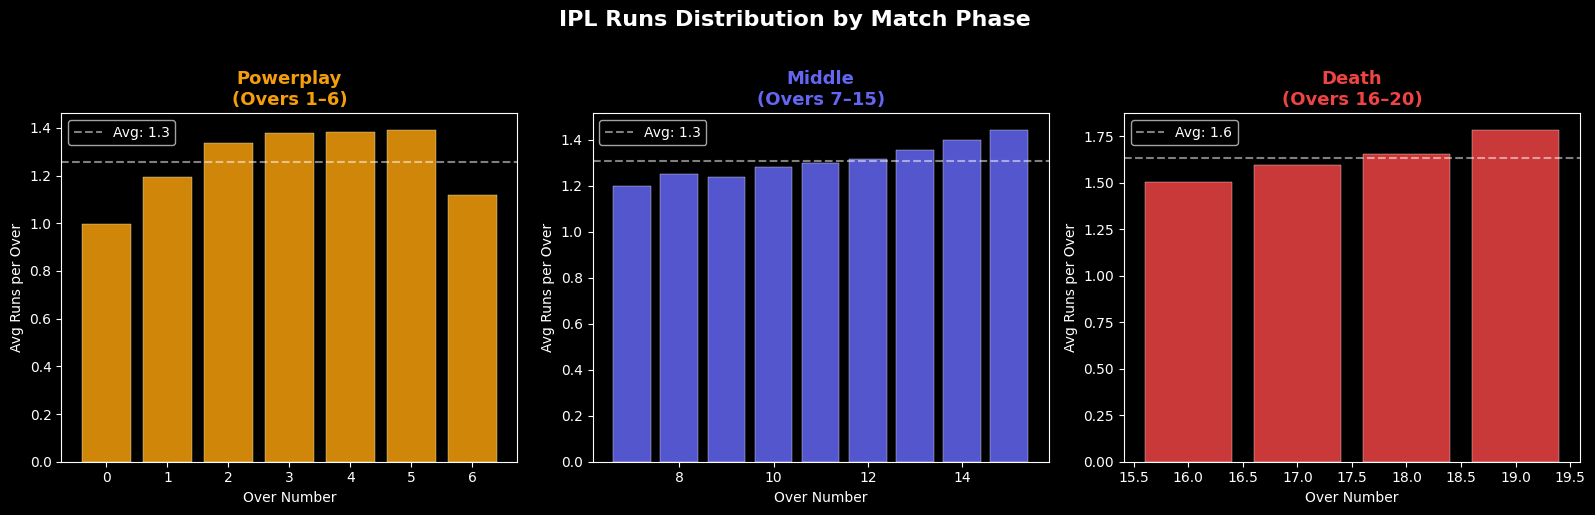

Plot saved to reports/


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('IPL Runs Distribution by Match Phase', fontsize=16, fontweight='bold', y=1.02)

phase_order = ['Powerplay', 'Middle', 'Death']
colors = ['#F59E0B', '#6366F1', '#EF4444']

for idx, phase in enumerate(phase_order):
    phase_data = master[master['phase'] == phase]
    
    # Runs per over in this phase
    over_runs = phase_data.groupby('over')['total_runs'].mean()
    
    axes[idx].bar(over_runs.index, over_runs.values, color=colors[idx], alpha=0.85, edgecolor='white', linewidth=0.3)
    axes[idx].set_title(f'{phase}\n(Overs {[1,7,16][idx]}–{[6,15,20][idx]})', fontsize=13, fontweight='bold', color=colors[idx])
    axes[idx].set_xlabel('Over Number')
    axes[idx].set_ylabel('Avg Runs per Over')
    axes[idx].axhline(over_runs.mean(), color='white', linestyle='--', alpha=0.5, label=f'Avg: {over_runs.mean():.1f}')
    axes[idx].legend(fontsize=10)

plt.tight_layout()
plt.savefig('../reports/01_runs_by_phase.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to reports/")

C:\Users\ishu6\AppData\Local\Temp\ipykernel_28568\2534939036.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  toss_decision_wins = matches_clean.groupby('toss_decision').apply(


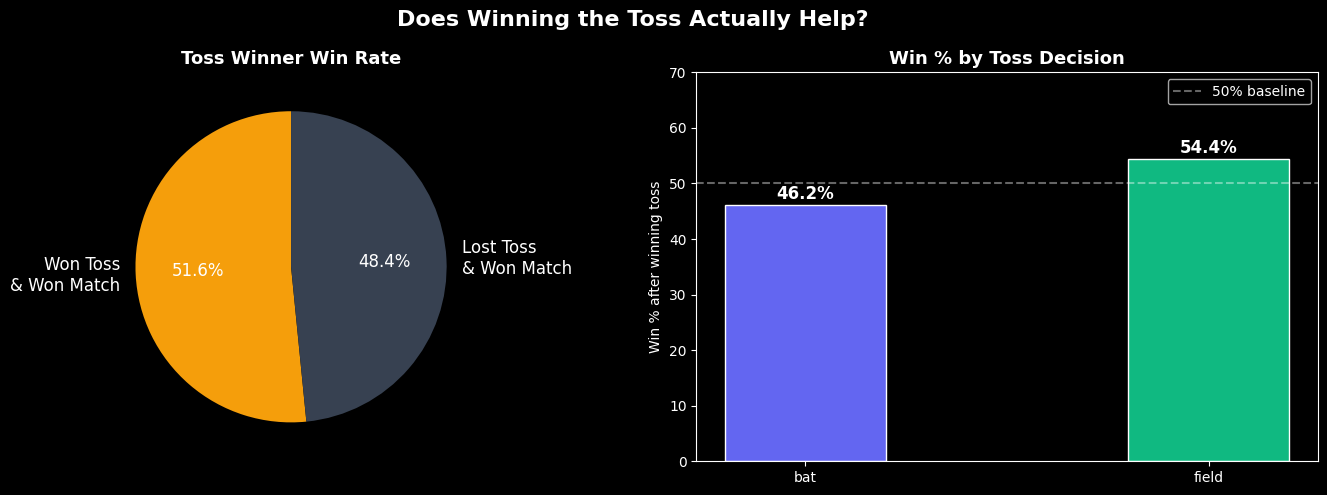


Key insight: Toss winners win 51.6% of matches
Plot saved!


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Does Winning the Toss Actually Help?', fontsize=16, fontweight='bold')

# Plot 1: Win % when won toss vs lost toss
matches_clean['won_toss'] = (matches_clean['toss_winner'] == matches_clean['winner']).astype(int)
toss_win_rate = matches_clean['won_toss'].mean() * 100

labels = ['Won Toss\n& Won Match', 'Lost Toss\n& Won Match']
values = [toss_win_rate, 100 - toss_win_rate]
colors_pie = ['#F59E0B', '#374151']
axes[0].pie(values, labels=labels, colors=colors_pie, autopct='%1.1f%%', 
            startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Toss Winner Win Rate', fontsize=13, fontweight='bold')

# Plot 2: Bat first vs field first win rates
toss_decision_wins = matches_clean.groupby('toss_decision').apply(
    lambda x: (x['toss_winner'] == x['winner']).mean() * 100
).reset_index()
toss_decision_wins.columns = ['toss_decision', 'win_pct']

bars = axes[1].bar(toss_decision_wins['toss_decision'], 
                    toss_decision_wins['win_pct'],
                    color=['#6366F1', '#10B981'], width=0.4, edgecolor='white')
axes[1].set_title('Win % by Toss Decision', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Win % after winning toss')
axes[1].set_ylim(0, 70)
axes[1].axhline(50, color='white', linestyle='--', alpha=0.4, label='50% baseline')
axes[1].legend()

for bar, val in zip(bars, toss_decision_wins['win_pct']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/02_toss_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nKey insight: Toss winners win {toss_win_rate:.1f}% of matches")
print("Plot saved!")

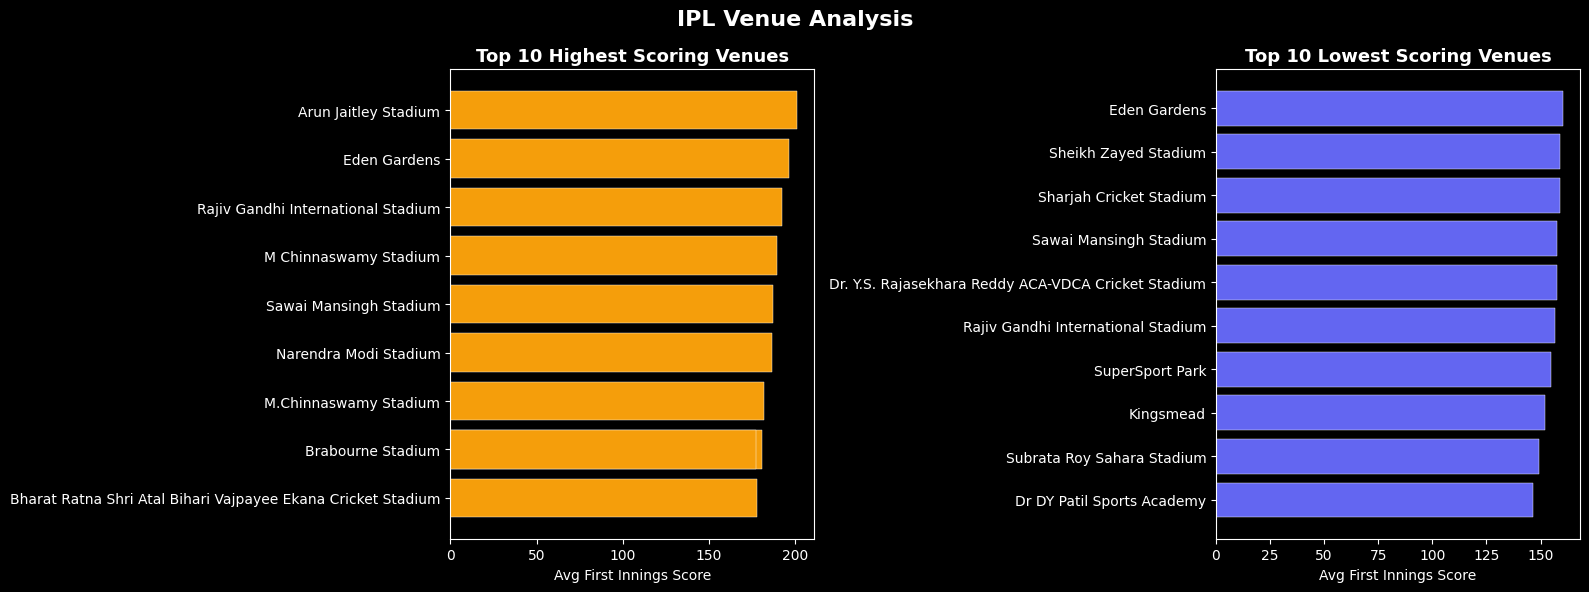

Plot saved!


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('IPL Venue Analysis', fontsize=16, fontweight='bold')

# Calculate avg first innings score per venue
first_innings = master[master['inning'] == 1]
venue_scores = (first_innings.groupby('venue')['total_runs']
                .sum()
                .reset_index())

# Get balls per venue to calculate proper average score
venue_balls = (first_innings[first_innings['is_wide'] == 0]
               .groupby('venue')
               .size()
               .reset_index(name='balls'))

venue_matches = (matches_clean.groupby('venue')
                 .size()
                 .reset_index(name='total_matches'))

venue_stats = venue_scores.merge(venue_matches, on='venue')
venue_stats = venue_stats[venue_stats['total_matches'] >= 10]  # only venues with 10+ matches
venue_stats['avg_score'] = (venue_stats['total_runs'] / venue_stats['total_matches']).round(1)
venue_stats = venue_stats.sort_values('avg_score', ascending=False)

# Plot 1: Top 10 highest scoring venues
top_venues = venue_stats.head(10)
axes[0].barh(top_venues['venue'].str.split(',').str[0], 
             top_venues['avg_score'], color='#F59E0B', edgecolor='white', linewidth=0.3)
axes[0].set_title('Top 10 Highest Scoring Venues', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Avg First Innings Score')
axes[0].invert_yaxis()

# Plot 2: Top 10 lowest scoring venues  
bottom_venues = venue_stats.tail(10)
axes[1].barh(bottom_venues['venue'].str.split(',').str[0],
             bottom_venues['avg_score'], color='#6366F1', edgecolor='white', linewidth=0.3)
axes[1].set_title('Top 10 Lowest Scoring Venues', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Avg First Innings Score')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../reports/03_venue_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

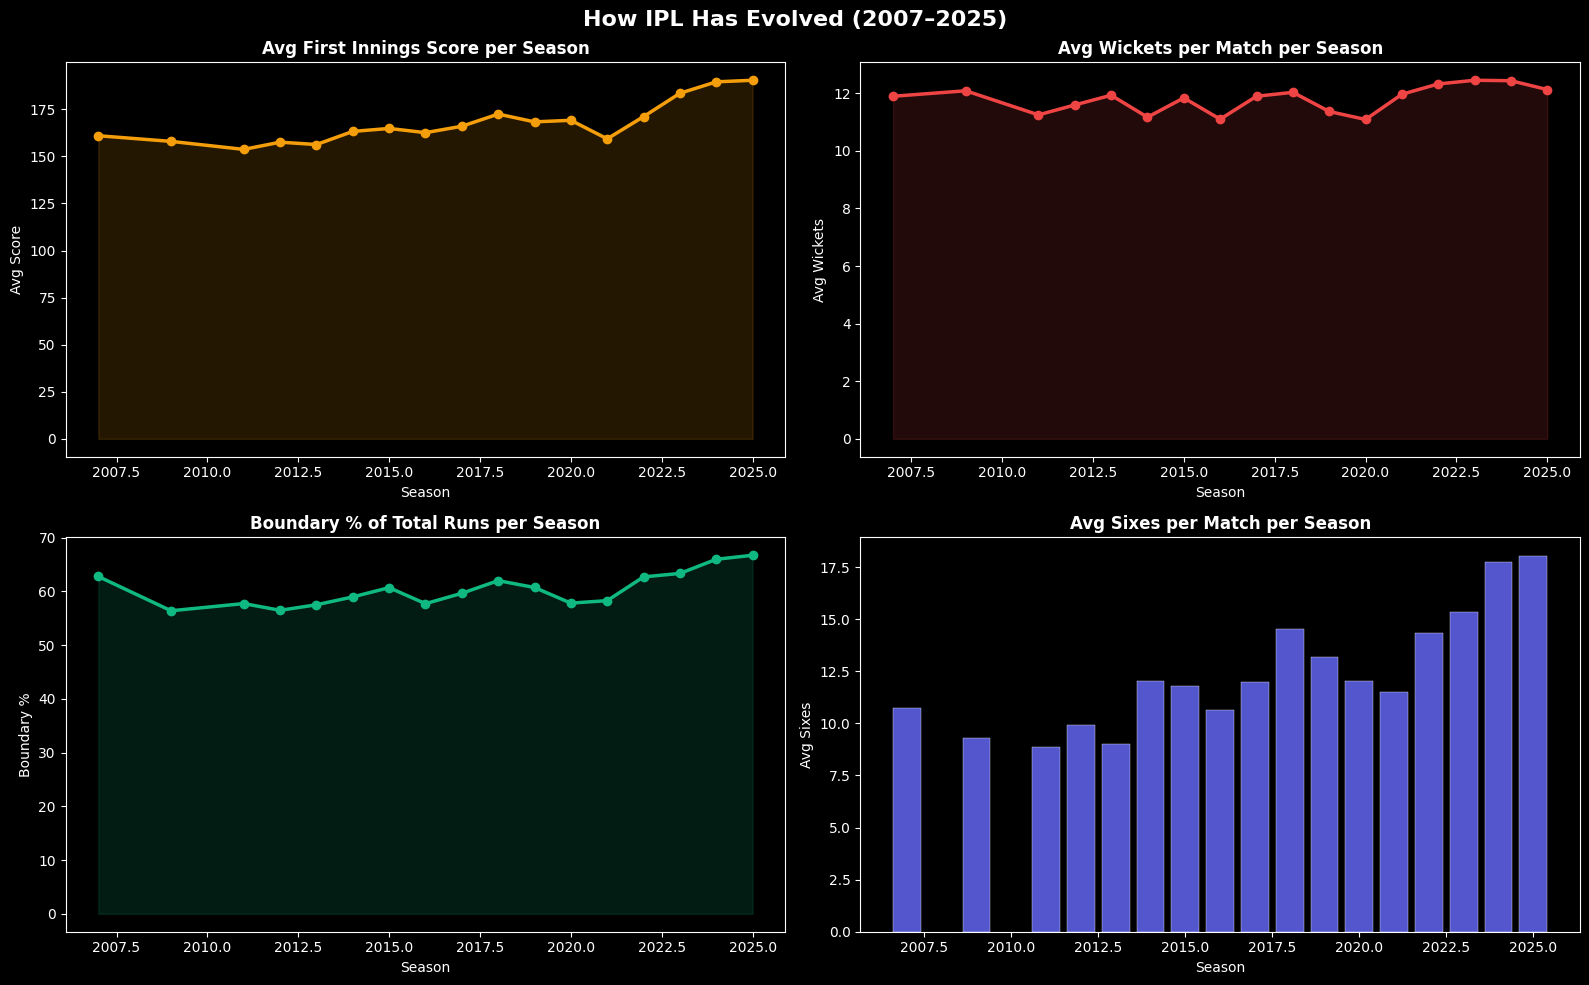

Season trends plot saved!


In [20]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('How IPL Has Evolved (2007–2025)', fontsize=16, fontweight='bold')

# Plot 1: Avg first innings score per season
season_scores = (master[master['inning'] == 1]
                 .groupby(['season', 'matchId'])['total_runs']
                 .sum()
                 .groupby('season').mean()
                 .reset_index())
season_scores.columns = ['season', 'avg_score']

axes[0,0].plot(season_scores['season'], season_scores['avg_score'], 
               color='#F59E0B', linewidth=2.5, marker='o', markersize=6)
axes[0,0].fill_between(season_scores['season'], season_scores['avg_score'], 
                        alpha=0.15, color='#F59E0B')
axes[0,0].set_title('Avg First Innings Score per Season', fontweight='bold')
axes[0,0].set_xlabel('Season')
axes[0,0].set_ylabel('Avg Score')

# Plot 2: Avg wickets per match per season
season_wickets = (master[master['is_wicket'] == 1]
                  .groupby(['season', 'matchId'])['is_wicket']
                  .sum()
                  .groupby('season').mean()
                  .reset_index())
season_wickets.columns = ['season', 'avg_wickets']

axes[0,1].plot(season_wickets['season'], season_wickets['avg_wickets'],
               color='#EF4444', linewidth=2.5, marker='o', markersize=6)
axes[0,1].fill_between(season_wickets['season'], season_wickets['avg_wickets'],
                        alpha=0.15, color='#EF4444')
axes[0,1].set_title('Avg Wickets per Match per Season', fontweight='bold')
axes[0,1].set_xlabel('Season')
axes[0,1].set_ylabel('Avg Wickets')

# Plot 3: Boundary % (4s and 6s as % of total runs) per season
master['is_four'] = (master['batsman_runs'] == 4).astype(int)
master['is_six'] = (master['batsman_runs'] == 6).astype(int)

season_boundaries = master.groupby('season').agg(
    fours=('is_four', 'sum'),
    sixes=('is_six', 'sum'),
    total_runs=('batsman_runs', 'sum')
).reset_index()
season_boundaries['boundary_pct'] = ((season_boundaries['fours'] * 4 + 
                                       season_boundaries['sixes'] * 6) / 
                                       season_boundaries['total_runs'] * 100)

axes[1,0].plot(season_boundaries['season'], season_boundaries['boundary_pct'],
               color='#10B981', linewidth=2.5, marker='o', markersize=6)
axes[1,0].fill_between(season_boundaries['season'], season_boundaries['boundary_pct'],
                        alpha=0.15, color='#10B981')
axes[1,0].set_title('Boundary % of Total Runs per Season', fontweight='bold')
axes[1,0].set_xlabel('Season')
axes[1,0].set_ylabel('Boundary %')

# Plot 4: Sixes per match per season
season_sixes = master.groupby(['season', 'matchId'])['is_six'].sum().groupby('season').mean().reset_index()
season_sixes.columns = ['season', 'avg_sixes']

axes[1,1].bar(season_sixes['season'], season_sixes['avg_sixes'],
              color='#6366F1', edgecolor='white', linewidth=0.3, alpha=0.85)
axes[1,1].set_title('Avg Sixes per Match per Season', fontweight='bold')
axes[1,1].set_xlabel('Season')
axes[1,1].set_ylabel('Avg Sixes')

plt.tight_layout()
plt.savefig('../reports/04_season_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("Season trends plot saved!")

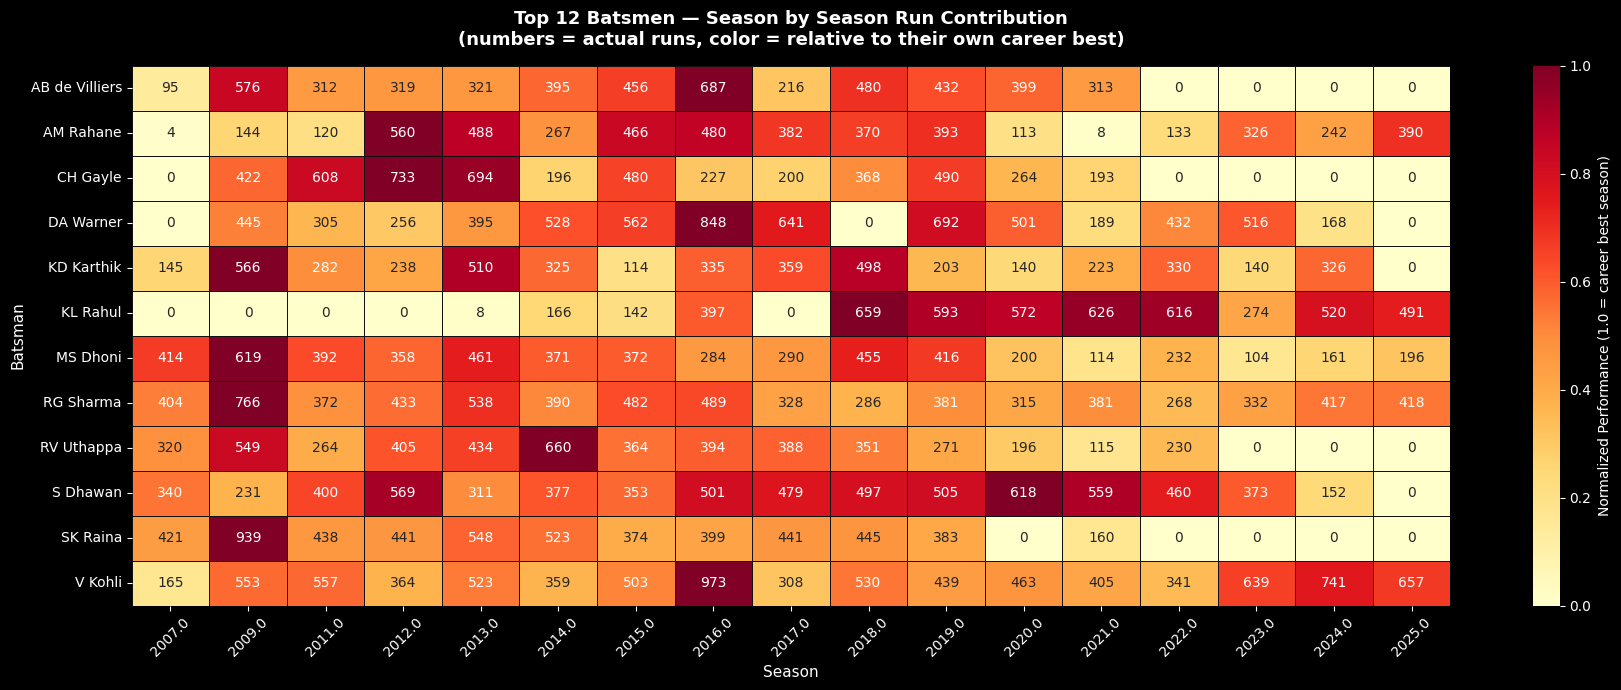

Player form heatmap saved!


In [21]:
fig, ax = plt.subplots(figsize=(18, 7))

# Get top 12 batsmen by total runs
top12 = (master[master['is_wide'] == 0]
         .groupby('batsman')['batsman_runs']
         .sum()
         .sort_values(ascending=False)
         .head(12)
         .index.tolist())

# Get their runs per season
heatmap_data = (master[(master['batsman'].isin(top12)) & (master['is_wide'] == 0)]
                .groupby(['batsman', 'season'])['batsman_runs']
                .sum()
                .unstack(fill_value=0))

# Normalize each player's row (0-1 scale) so we compare form not volume
heatmap_normalized = heatmap_data.div(heatmap_data.max(axis=1), axis=0)

sns.heatmap(heatmap_normalized, 
            annot=heatmap_data.values,
            fmt='d',
            cmap='YlOrRd',
            linewidths=0.5,
            linecolor='#111',
            ax=ax,
            cbar_kws={'label': 'Normalized Performance (1.0 = career best season)'})

ax.set_title('Top 12 Batsmen — Season by Season Run Contribution\n(numbers = actual runs, color = relative to their own career best)', 
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Season', fontsize=11)
ax.set_ylabel('Batsman', fontsize=11)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('../reports/05_player_form_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Player form heatmap saved!")

In [22]:
print("=" * 50)
print("EDA COMPLETE — SUMMARY OF KEY FINDINGS")
print("=" * 50)

print(f"""
 DATASET:
   • {len(matches_clean)} matches across 17 seasons (2007–2025)
   • {len(deliveries_clean)} deliveries
   • {deliveries_clean['batsman'].nunique()} unique batsmen
   • {deliveries_clean['bowler'].nunique()} unique bowlers
   • {matches_clean['venue'].nunique()} unique venues

 BATTING:
   • All-time top scorer: {master[master['is_wide']==0].groupby('batsman')['batsman_runs'].sum().idxmax()}
   • Highest scoring venue: {master[master['inning']==1].groupby('venue')['total_runs'].sum().idxmax().split(',')[0]}

 BOWLING:
   • All-time top wicket taker: {master[master['is_wicket']==1].groupby('bowler')['is_wicket'].sum().idxmax()}

 TRENDS:
   • Scoring surge post-2020 ✓
   • Sixes increasing year on year ✓  
   • Wicket rate stable ✓
   • Boundary % rising ✓

 FILES SAVED:
   • reports/01_runs_by_phase.png
   • reports/02_toss_impact.png
   • reports/03_venue_analysis.png
   • reports/04_season_trends.png
   • reports/05_player_form_heatmap.png
""")

EDA COMPLETE — SUMMARY OF KEY FINDINGS

 DATASET:
   • 1146 matches across 17 seasons (2007–2025)
   • 278205 deliveries
   • 704 unique batsmen
   • 551 unique bowlers
   • 59 unique venues

 BATTING:
   • All-time top scorer: V Kohli
   • Highest scoring venue: Eden Gardens

 BOWLING:
   • All-time top wicket taker: YS Chahal

 TRENDS:
   • Scoring surge post-2020 ✓
   • Sixes increasing year on year ✓  
   • Wicket rate stable ✓
   • Boundary % rising ✓

 FILES SAVED:
   • reports/01_runs_by_phase.png
   • reports/02_toss_impact.png
   • reports/03_venue_analysis.png
   • reports/04_season_trends.png
   • reports/05_player_form_heatmap.png

